In [ ]:
import pandas as pd

# Step 1: Load the dataset
df = pd.read_csv(r"SSG_Healthcare_Courses_Cleaned.csv", encoding="ISO-8859-1")

# Check size and first few rows
print("Shape:", df.shape)
display(df.head(3))

# Basic structure and missing values
df.info()
print("\nMissing values per column (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (1703, 13)


,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidiy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.0,0,Part time,More than 1 year,2800.0,NaN,NaN,NaN,2015
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.0,0,Part time,More than 1 year,2800.0,NaN,NaN,NaN,2015
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.0,0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703 entries, 0 to 1702
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID                                 1703 non-null   int64  
 1   Course Title                       1703 non-null   object 
 2   Course Description                 1703 non-null   object 
 3   Training Company                   1703 non-null   object 
 4   Course Fee                         1703 non-null   float64
 5   Course Fee after Maximum Subsidiy  1699 non-null   object 
 6   Course Type                        1703 non-null   object 
 7   Course Duration                    1703 non-null   object 
 8   Course Hours                       1703 non-null   float64
 9   No. of Learners                    640 non-null    float64
 10  No. of Learners who Rated          538 non-null    float64
 11  Ratings out of 5                   538 non-null    float

Number of courses with ratings: 538

Ratings summary:
count    538.000000
mean       4.292379
std        0.411200
min        1.000000
25%        4.100000
50%        4.300000
75%        4.500000
max        5.000000
Name: Ratings out of 5, dtype: float64


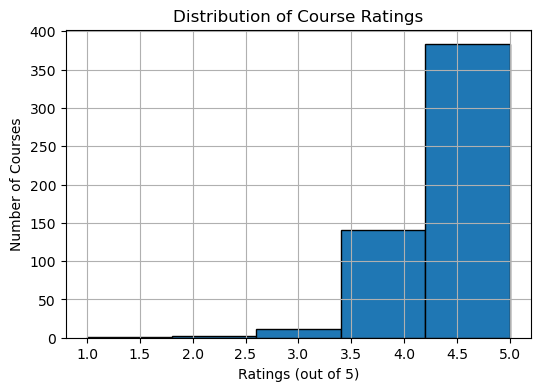

In [2]:
import matplotlib.pyplot as plt

# Step 2: Explore the rating column
print("Number of courses with ratings:", df["Ratings out of 5"].notna().sum())

# Show descriptive stats
print("\nRatings summary:")
print(df["Ratings out of 5"].describe())

# Plot distribution of ratings
plt.figure(figsize=(6,4))
df["Ratings out of 5"].hist(bins=5, edgecolor="black")
plt.title("Distribution of Course Ratings")
plt.xlabel("Ratings (out of 5)")
plt.ylabel("Number of Courses")
plt.show()

**Univariate analysis**

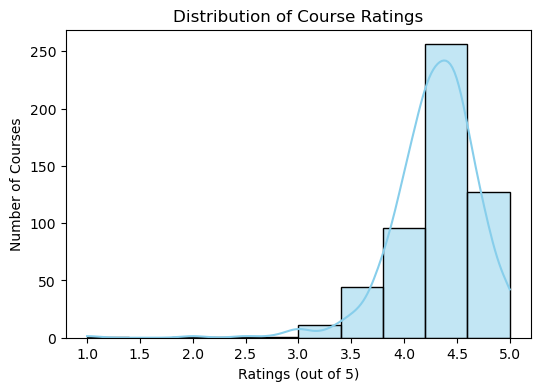

count    538.000000
mean       4.292379
std        0.411200
min        1.000000
25%        4.100000
50%        4.300000
75%        4.500000
max        5.000000
Name: Ratings out of 5, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Univariate analysis on Ratings
plt.figure(figsize=(6,4))
sns.histplot(df['Ratings out of 5'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Course Ratings')
plt.xlabel('Ratings (out of 5)')
plt.ylabel('Number of Courses')
plt.show()

# Summary statistics
print(df['Ratings out of 5'].describe())


**Bivariate Analysis — Course Fee vs Ratings**

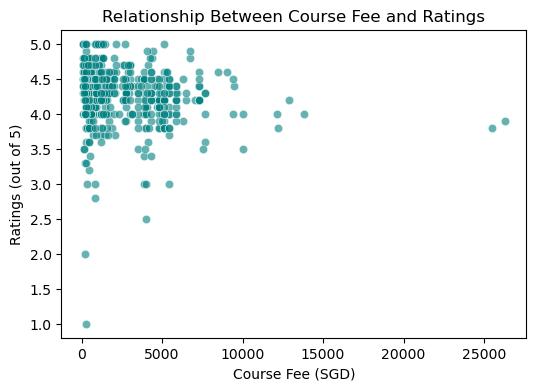

Correlation between Course Fee and Ratings: -0.174


In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Course Fee", y="Ratings out of 5", color="teal", alpha=0.6)
plt.title("Relationship Between Course Fee and Ratings")
plt.xlabel("Course Fee (SGD)")
plt.ylabel("Ratings (out of 5)")
plt.show()

# Calculate correlation
correlation = df["Course Fee"].corr(df["Ratings out of 5"])
print(f"Correlation between Course Fee and Ratings: {correlation:.3f}")


**Bivariate Analysis — Course Hours vs Ratings**

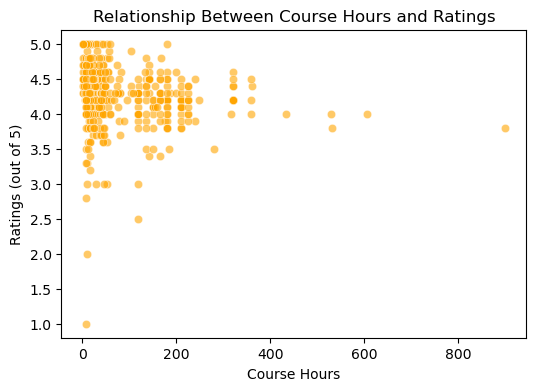

Correlation between Course Hours and Ratings: -0.178


In [5]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Course Hours", y="Ratings out of 5", color="orange", alpha=0.6)
plt.title("Relationship Between Course Hours and Ratings")
plt.xlabel("Course Hours")
plt.ylabel("Ratings (out of 5)")
plt.show()

# Calculate correlation
correlation_hours = df["Course Hours"].corr(df["Ratings out of 5"])
print(f"Correlation between Course Hours and Ratings: {correlation_hours:.3f}")

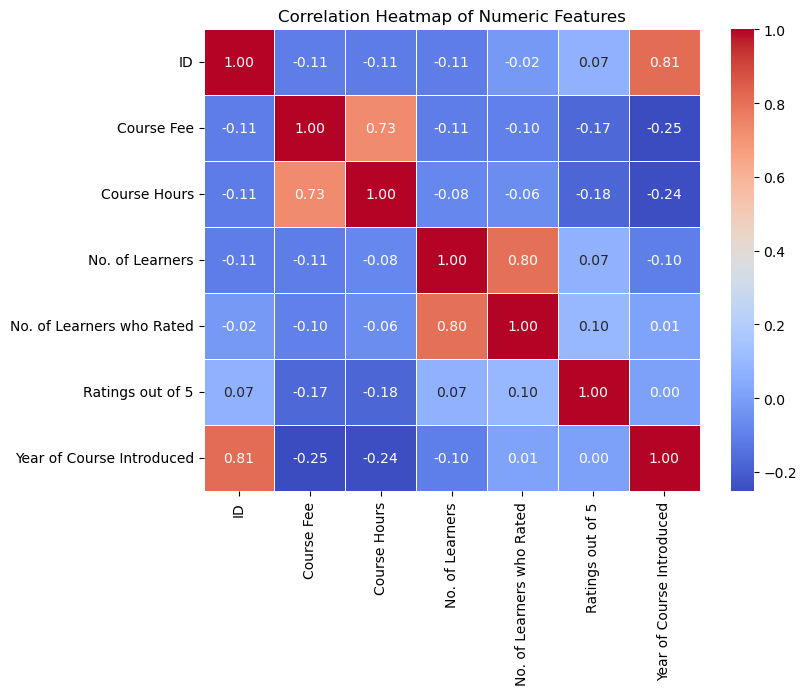

In [6]:
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns  # only numeric columns
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [7]:
# Step 3: Prepare dataset for modeling

# Keep only courses that have ratings
df_model = df.dropna(subset=["Ratings out of 5"]).copy()

# Create binary classification label
df_model["High_Rating_Label"] = (df_model["Ratings out of 5"] >= 4).astype(int)

# Check class balance
print("Label distribution (1 = High Rating >=4):")
print(df_model["High_Rating_Label"].value_counts(normalize=True).rename("Proportion"))

# Show sample
df_model[["Ratings out of 5", "High_Rating_Label"]].head(10)


Label distribution (1 = High Rating >=4):
High_Rating_Label
1    0.864312
0    0.135688
Name: Proportion, dtype: float64


,Ratings out of 5,High_Rating_Label
26,4.3,1
27,4.2,1
32,4.6,1
37,4.0,1
38,4.5,1
39,4.5,1
40,4.8,1
44,4.2,1
45,4.3,1
46,4.4,1


In [8]:
# Step 4: Select relevant features for modeling

features_to_use = [
    "Course Fee",
    "Course Hours",
    "Course Type",
    "Course Duration",
    "Training Company",
    "Year of Course Introduced"
]

df_features = df_model[features_to_use + ["Ratings out of 5", "High_Rating_Label"]].copy()

# Quick check
print("Shape:", df_features.shape)
df_features.head(5)


Shape: (538, 8)


,Course Fee,Course Hours,Course Type,Course Duration,Training Company,Year of Course Introduced,Ratings out of 5,High_Rating_Label
26,140.0,10.0,Part time,1-2 days,Changi Simei Community Club,2017,4.3,1
27,240.0,10.0,Part Time,1-2 days,"Confucius Institute, Nanyang Technological Uni...",2017,4.2,1
32,160.0,8.0,Part Time,1-2 days,Nanyang Polytechnic,2017,4.6,1
37,160.0,10.0,Part Time,1-2 days,Toa Payoh East Community Club,2017,4.0,1
38,160.0,10.0,Part Time,1-2 days,Toa Payoh East Community Club,2017,4.5,1


In [9]:
from sklearn.preprocessing import LabelEncoder

# Step 5: Encode categorical features
categorical_cols = ["Course Type", "Course Duration", "Training Company"]

le = LabelEncoder()
for col in categorical_cols:
    df_features[col] = le.fit_transform(df_features[col].astype(str))

# Check the result
df_features.head(5)

,Course Fee,Course Hours,Course Type,Course Duration,Training Company,Year of Course Introduced,Ratings out of 5,High_Rating_Label
26,140.0,10.0,3,0,6,2017,4.3,1
27,240.0,10.0,2,0,7,2017,4.2,1
32,160.0,8.0,2,0,26,2017,4.6,1
37,160.0,10.0,2,0,52,2017,4.0,1
38,160.0,10.0,2,0,52,2017,4.5,1


**Prepare data for Regression only**

In [10]:
from sklearn.model_selection import train_test_split

# Step 6A: Prepare data for regression (predicting actual rating value)
X_reg = df_features.drop(columns=["Ratings out of 5", "High_Rating_Label"])
y_reg = df_features["Ratings out of 5"]

# Split into training and test sets (70% train, 30% test)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Confirm results
print("Training data shape:", X_train_reg.shape)
print("Testing data shape:", X_test_reg.shape)



Training data shape: (376, 6)
Testing data shape: (162, 6)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Step 7A: Train Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# Predict on test data
y_pred_reg = reg_model.predict(X_test_reg)

# Evaluate model performance
r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("Linear Regression Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Linear Regression Model Performance:
R² Score: 0.0015
Mean Absolute Error (MAE): 0.2875
Root Mean Squared Error (RMSE): 0.4589


**Prepare data for Classification - Logistic Regression**

In [12]:
from sklearn.model_selection import train_test_split

# Step 7B: Prepare data for classification
X_class = df_features.drop(columns=["Ratings out of 5", "High_Rating_Label"])
y_class = df_features["High_Rating_Label"]

# Split into 70% training and 30% testing
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)

print("Training data shape:", X_train_clf.shape)
print("Testing data shape:", X_test_clf.shape)
print("\nLabel distribution in training set:")
print(y_train_clf.value_counts(normalize=True))


Training data shape: (376, 6)
Testing data shape: (162, 6)

Label distribution in training set:
High_Rating_Label
1    0.864362
0    0.135638
Name: proportion, dtype: float64


Logistic Regression Model Performance:
Accuracy: 0.8642
Precision: 0.8642
Recall: 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.86      1.00      0.93       140

    accuracy                           0.86       162
   macro avg       0.43      0.50      0.46       162
weighted avg       0.75      0.86      0.80       162



C:\Users\kenko\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kenko\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kenko\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


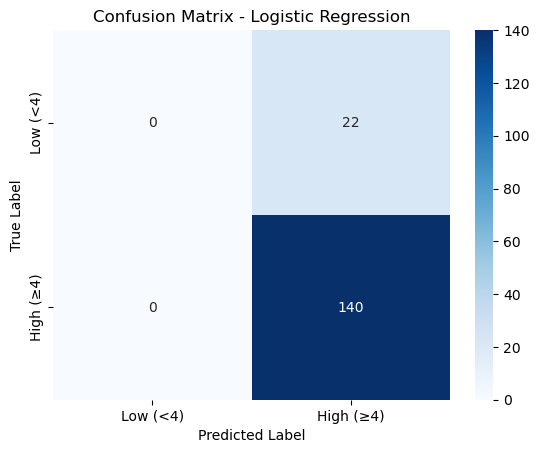

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 8: Train Logistic Regression model
clf_model = LogisticRegression(max_iter=1000, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

# Predict on test data
y_pred_clf = clf_model.predict(X_test_clf)

# Evaluate
acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_clf, y_pred_clf))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low (<4)", "High (≥4)"], yticklabels=["Low (<4)", "High (≥4)"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Train the Decision Tree Classifier**

Decision Tree Model Performance:
Accuracy: 0.8209876543209876

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.23      0.26        22
           1       0.88      0.91      0.90       140

    accuracy                           0.82       162
   macro avg       0.59      0.57      0.58       162
weighted avg       0.80      0.82      0.81       162



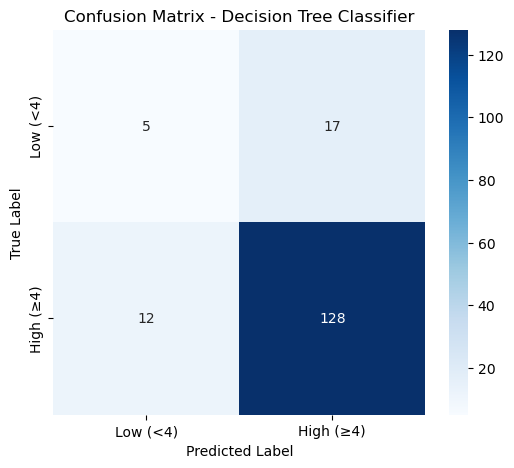

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize and train the model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_clf, y_train_clf)

# Step 2: Make predictions
y_pred_tree = tree_model.predict(X_test_clf)

# Step 3: Evaluate performance
print("Decision Tree Model Performance:")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_tree))
print("\nDetailed Classification Report:")
print(classification_report(y_test_clf, y_pred_tree))

# Step 4: Confusion matrix visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_tree),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low (<4)', 'High (≥4)'],
            yticklabels=['Low (<4)', 'High (≥4)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.show()


In [51]:
DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=42)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: title={'center': 'Feature Importance'}>

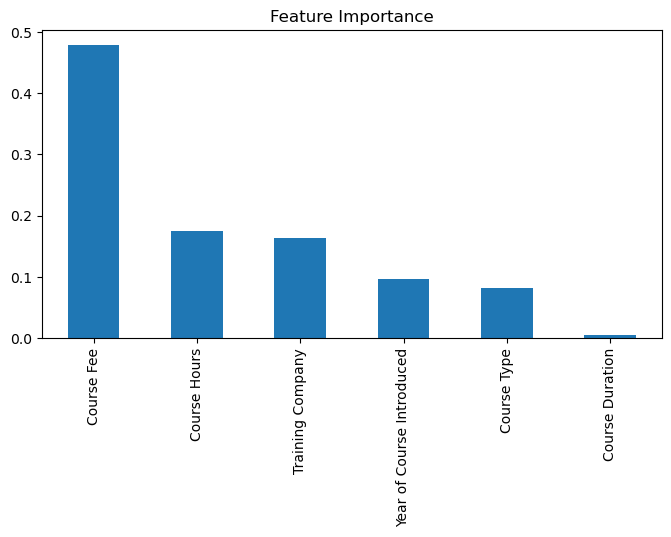

In [16]:
import pandas as pd
importance = pd.Series(tree_model.feature_importances_, index=X_train_clf.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(8,4), title='Feature Importance')


**Enhanced Feature Importance Visualization**

C:\Users\kenko\AppData\Local\Temp\ipykernel_8764\188620933.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=importance_df, palette="Blues_d")


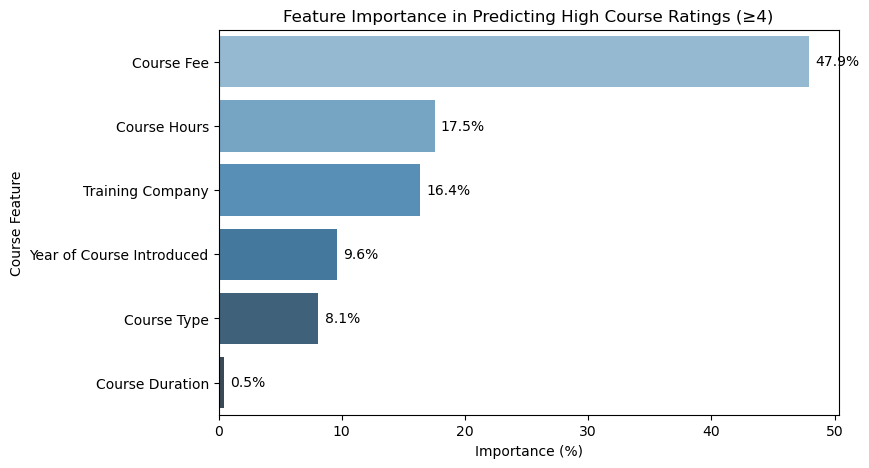

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create DataFrame for feature importance
importance_df = pd.DataFrame({
    "Feature": X_train_clf.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Convert to percentage for clearer explanation
importance_df["Importance (%)"] = importance_df["Importance"] * 100

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x="Importance (%)", y="Feature", data=importance_df, palette="Blues_d")

# Add value labels
for i, v in enumerate(importance_df["Importance (%)"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.title("Feature Importance in Predicting High Course Ratings (≥4)", fontsize=12)
plt.xlabel("Importance (%)")
plt.ylabel("Course Feature")
plt.show()

In [44]:
# Filter courses with available ratings
rated_courses = df[df["Ratings out of 5"].notnull()]

# Display a few examples
rated_courses[["Course Title", "Training Company", "Course Fee", "Ratings out of 5"]].head(10)

,Course Title,Training Company,Course Fee,Ratings out of 5
26,SkillsFuture@PA TCM Gua Sha (Stage 1),Changi Simei Community Club,140.00,4.3
27,Discovering TCM Acupuncture,"Confucius Institute, Nanyang Technological Uni...",240.00,4.2
32,EAT HEALTHY & STAY BEAUTIFUL THROUGH TCM-INFUS...,Nanyang Polytechnic,160.00,4.6
37,SkillsFuture@PA TCM Herbal Diet,Toa Payoh East Community Club,160.00,4.0
38,SkillsFuture@PA Acupressure Massage,Toa Payoh East Community Club,160.00,4.5
39,Introductory Course In Traditional Chinese Med...,"Confucius Institute, Nanyang Technological Uni...",498.00,4.5
40,Certificate in Bridging Studies for Enrolled N...,Nanyang Polytechnic,1289.91,4.8
44,Post Diploma Certificate in Advanced Critical ...,Ngee Ann Polytechnic,6472.80,4.2
45,Post Diploma Certificate in Applied Sciences i...,Ngee Ann Polytechnic,4906.80,4.3
46,Post Diploma Certificate in Advanced Clinical ...,Ngee Ann Polytechnic,9448.20,4.4


**Top 10 Highest-Rated Courses: Course Fee by Training Provider**

In [19]:
# Top 10 courses by rating
top_rated = rated_courses.sort_values(by="Ratings out of 5", ascending=False)

top_rated[["Course Title", "Training Company", "Course Fee", "Ratings out of 5"]].head(10)

,Course Title,Training Company,Course Fee,Ratings out of 5
1449,Hematological System Series [For registered TC...,SCTCM,99.0,5.0
142,Navigating Medical Law and Ethics in the Curre...,National University Of Singapore,950.0,5.0
1160,The Application and Use of Genetic Counselling...,National University Of Singapore,1350.0,5.0
933,"Patient Assessment in Prehospital Care, Airway...",Hmi Institute Of Health Sciences Pte. Ltd.,990.0,5.0
932,MOBILITY AND AMBULATION ASSISTANCE IN NURSING ...,Hmi Institute Of Health Sciences Pte. Ltd.,100.0,5.0
857,Standard First-Aid Course with CPR (HO)+AED Co...,Dynamic Safety Pte. Ltd.,160.0,5.0
860,NSA- Basic modern rehabilitation for musculosk...,Fei Yue Community Services,250.0,5.0
892,Prehospital Emergency Care,Hmi Institute Of Health Sciences Pte. Ltd.,1188.0,5.0
781,Nervous System Series (Central Nervous System)...,SCTCM,99.0,5.0
167,NSA - Chronic Diseases of TCM Management Modul...,Fei Yue Community Services,260.0,5.0


C:\Users\kenko\AppData\Local\Temp\ipykernel_8764\947178438.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


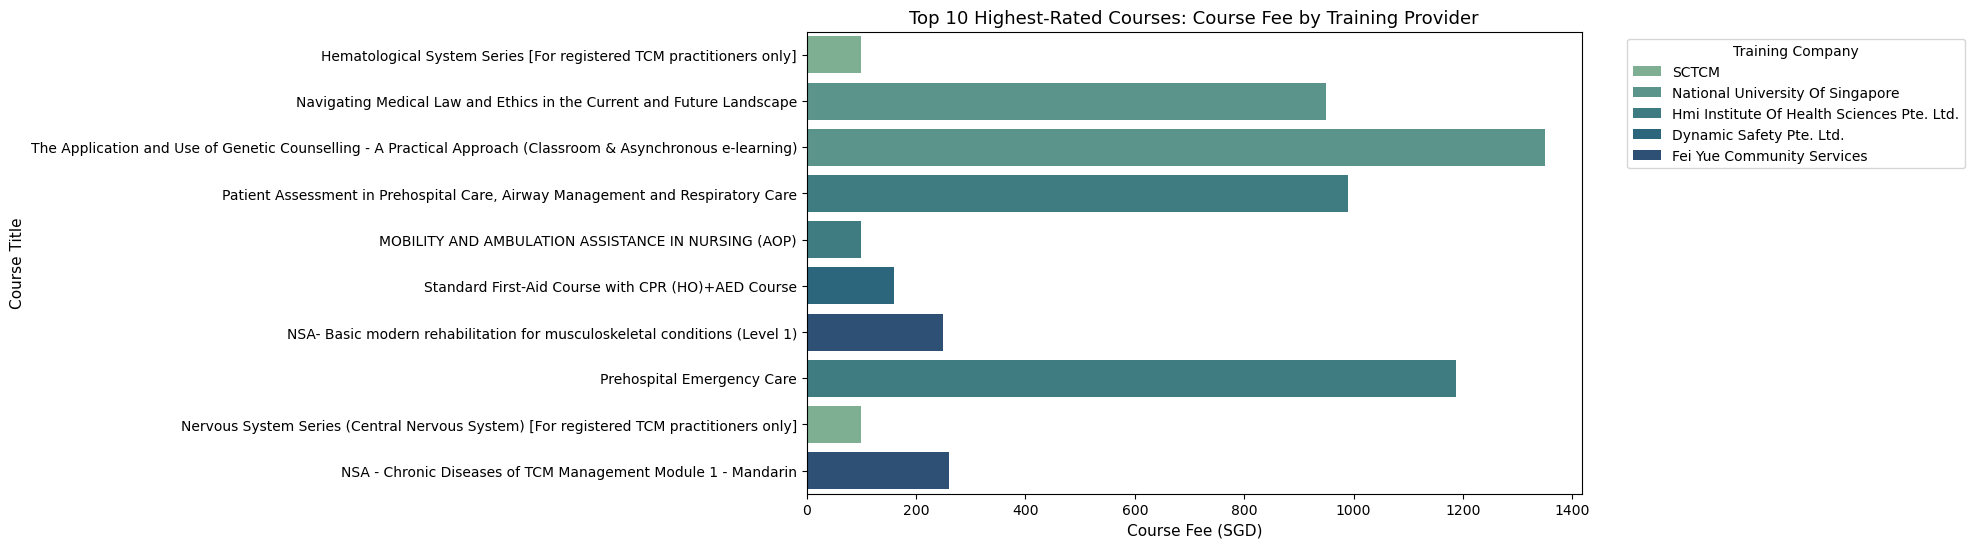

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
top10 = top_rated.head(10)

# Create horizontal bar chart
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x="Course Fee",
    y="Course Title",
    hue="Training Company",
    dodge=False,
    palette="crest"
)

# Add labels and title
plt.title("Top 10 Highest-Rated Courses: Course Fee by Training Provider", fontsize=13)
plt.xlabel("Course Fee (SGD)", fontsize=11)
plt.ylabel("Course Title", fontsize=11)

# Move legend to the side and clean layout
plt.legend(title="Training Company", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Top Training Companies by Number of Rated Courses**

In [20]:
# Count how many rated courses each training company has
rating_counts = (
    rated_courses["Training Company"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Training Company", "Training Company": "Number of Rated Courses"})
)

rating_counts.head(10)

,Number of Rated Courses,count
0,Hmi Institute Of Health Sciences Pte. Ltd.,89
1,Nanyang Polytechnic,80
2,National University Of Singapore,73
3,Republic Polytechnic,37
4,Ntuc Learninghub Pte. Ltd.,34
5,Fei Yue Community Services,24
6,Ngee Ann Polytechnic,18
7,Singapore Management University,18
8,Singapore Institute Of Technology,18
9,Temasek Polytechnic,15


C:\Users\kenko\AppData\Local\Temp\ipykernel_8764\2565899215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


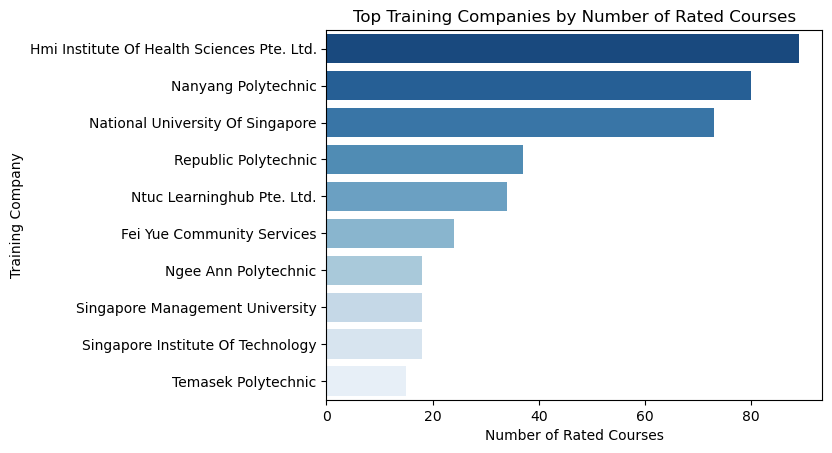

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure consistent column names
rating_counts.columns = ["Training_Company", "Number_of_Rated_Courses"]

# Plot top 10 training companies with most rated courses
sns.barplot(
    data=rating_counts.head(10),
    x="Number_of_Rated_Courses",
    y="Training_Company",
    palette="Blues_r"
)

plt.title("Top Training Companies by Number of Rated Courses")
plt.xlabel("Number of Rated Courses")
plt.ylabel("Training Company")
plt.show()
